In [1]:
!pip install -q transformers==4.41.2 peft==0.11.1 accelerate==0.31.0 datasets psutil sentencepiece

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
import psutil
import gc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.metrics.pairwise import cosine_similarity

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)

from peft import AdaLoraConfig, get_peft_model

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.4/309.4 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 40.7 MB/s eta 0:00:00
Mounted at /content/drive


Total: 5914
Sentiment
Positive    3151
Negative    1671
Neutral     1092
Name: count, dtype: int64


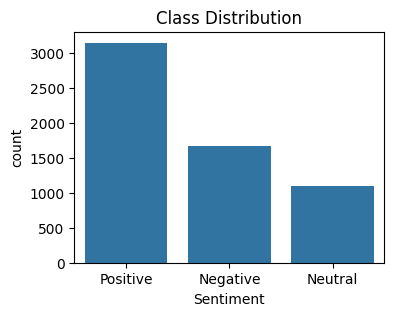


Label Mapping:
Negative: 0
Neutral: 1
Positive: 2
4731 591 592


In [2]:
file_path = "/content/drive/MyDrive/Laptop + Restaurant - ABSA.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')
df = df[['Text','Sentiment']].dropna()

print("Total:", len(df))
print(df['Sentiment'].value_counts())

plt.figure(figsize=(4,3))
sns.countplot(data=df, x='Sentiment')
plt.title("Class Distribution")
plt.show()

df['Sentiment'] = df['Sentiment'].str.strip()

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Sentiment'])

print("\nLabel Mapping:")
for i,l in enumerate(label_encoder.classes_):
    print(f"{l}: {i}")

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['Text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(len(train_texts), len(val_texts), len(test_texts))

In [3]:
base_model = "microsoft/deberta-v3-base"

tokenizer = AutoTokenizer.from_pretrained(base_model)

train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_enc   = tokenizer(val_texts, truncation=True, padding=True, max_length=128)
test_enc  = tokenizer(test_texts, truncation=True, padding=True, max_length=128)


class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = Dataset(train_enc, train_labels)
val_dataset = Dataset(val_enc, val_labels)
test_dataset = Dataset(test_enc, test_labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [4]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, preds)*100
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")

    return {
        "Accuracy": acc,
        "Precision": prec*100,
        "Recall": rec*100,
        "F1 Score": f1*100
    }

In [5]:
print("=== ADALORA TRAINING ===")

model = AutoModelForSequenceClassification.from_pretrained(
    base_model,
    num_labels=len(label_encoder.classes_)
)

adalora_config = AdaLoraConfig(
    task_type="SEQ_CLS",

    init_r=12,
    target_r=4,

    beta1=0.85,
    beta2=0.85,

    tinit=200,
    tfinal=1000,
    deltaT=10,

    lora_alpha=32,
    lora_dropout=0.1,

    target_modules=["query_proj","value_proj","output.dense"]
)

model = get_peft_model(model, adalora_config)
model.print_trainable_parameters()

training_args = TrainingArguments(
    output_dir="./adalora-absa",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-4,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=5,

    fp16=True,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    save_total_limit=2,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

start_time = time.time()
trainer.train()
train_time = time.time() - start_time

metrics = trainer.evaluate(test_dataset)

=== ADALORA TRAINING ===


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,219,395 || all params: 185,643,894 || trainable%: 0.6568


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:477: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1 score
1,1.118800,1.004085,53.299492,17.766497,33.333333,23.178808
2,0.916000,0.695002,74.111675,48.186996,59.384723,53.196046
3,0.635900,0.632765,72.758037,58.086844,59.306487,56.595859
4,0.616800,0.628786,72.588832,60.028260,60.988150,59.466270
5,0.587300,0.639660,73.434856,63.202662,62.285576,62.138157


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: Futur

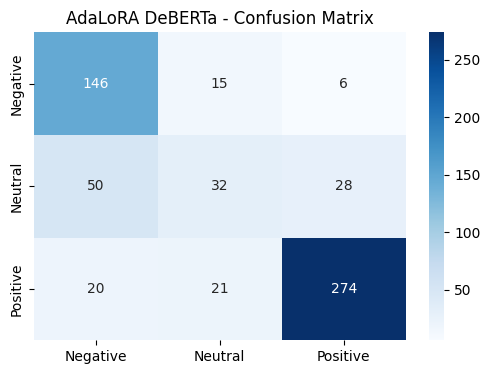

In [6]:
preds_out = trainer.predict(test_dataset)

preds = np.argmax(preds_out.predictions, axis=1)

cm = confusion_matrix(
    test_dataset.labels,
    preds,
    labels=[0,1,2]
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("AdaLoRA DeBERTa - Confusion Matrix")
plt.show()

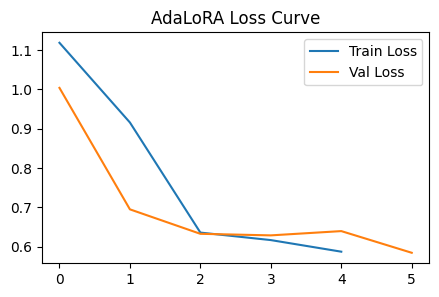

In [7]:
history = trainer.state.log_history

train_loss = [x["loss"] for x in history if "loss" in x and "eval_loss" not in x]
val_loss = [x["eval_loss"] for x in history if "eval_loss" in x]

plt.figure(figsize=(5,3))

plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Val Loss")

plt.title("AdaLoRA Loss Curve")
plt.legend()
plt.grid(False)

plt.show()

In [8]:
preds_out = trainer.predict(test_dataset)

probs = torch.softmax(torch.tensor(preds_out.predictions), dim=1)

confidence = probs.max(dim=1).values.numpy().mean() * 100

labels_onehot = np.eye(len(label_encoder.classes_))[test_dataset.labels]

similarity = cosine_similarity(
    preds_out.predictions,
    labels_onehot
).mean() * 100


results = {
    "Model": "AdaLoRA DeBERTa",

    "Accuracy": f"{metrics['eval_Accuracy']:.2f}%",
    "Precision": f"{metrics['eval_Precision']:.2f}%",
    "Recall": f"{metrics['eval_Recall']:.2f}%",
    "F1 Score": f"{metrics['eval_F1 Score']:.2f}%",

    "Similarity": f"{similarity:.2f}%",
    "Confidence": f"{confidence:.2f}%",

    "Training Time (s)": f"{train_time:.2f}",
    "Trainable Params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "GPU Memory (GB)": f"{torch.cuda.max_memory_allocated()/1024**3:.4f}"
}

pd.DataFrame([results])

,Model,Accuracy,Precision,Recall,F1 Score,Similarity,Confidence,Training Time (s),Trainable Params,GPU Memory (GB)
0,AdaLoRA DeBERTa,76.35%,67.87%,67.83%,66.72%,-0.30%,78.96%,627.43,1219395,1.6764
